<a href="https://colab.research.google.com/github/amenidhawadi/heart/blob/public/notb2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cellule 1: Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Bibliothèques importées")

Bibliothèques importées


In [2]:
# Cellule 2: Chargement et préparation des données
from google.colab import files
uploaded = files.upload()

import io
df = pd.read_csv(io.BytesIO(uploaded['heart.csv']))

print("Dataset chargé. Shape:", df.shape)
df.head()

Saving heart.csv to heart.csv
Dataset chargé. Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# Cellule 3: Prétraitement avancé
# 3.1 Gestion des valeurs aberrantes (Cholesterol = 0 sont des valeurs manquantes)
print(f"Cholesterol = 0 avant traitement: {(df['Cholesterol'] == 0).sum()}")
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())
print(f"Cholesterol = 0 après traitement: {(df['Cholesterol'] == 0).sum()}")

# 3.2 Gestion des outliers dans RestingBP (valeurs > 200 ou < 80)
print(f"RestingBP aberrant avant: {((df['RestingBP'] < 80) | (df['RestingBP'] > 200)).sum()}")
df['RestingBP'] = df['RestingBP'].clip(lower=80, upper=200)

# 3.3 Encodage des variables catégorielles
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"{col} encodé: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 3.4 FastingBS est déjà binaire, on le garde tel quel
# 3.5 Séparation features (X) et target (y)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

Cholesterol = 0 avant traitement: 172
Cholesterol = 0 après traitement: 0
RestingBP aberrant avant: 1
Sex encodé: {'F': np.int64(0), 'M': np.int64(1)}
ChestPainType encodé: {'ASY': np.int64(0), 'ATA': np.int64(1), 'NAP': np.int64(2), 'TA': np.int64(3)}
RestingECG encodé: {'LVH': np.int64(0), 'Normal': np.int64(1), 'ST': np.int64(2)}
ExerciseAngina encodé: {'N': np.int64(0), 'Y': np.int64(1)}
ST_Slope encodé: {'Down': np.int64(0), 'Flat': np.int64(1), 'Up': np.int64(2)}

Features shape: (918, 11)
Target shape: (918,)


In [4]:
# Cellule 4: Normalisation/Standardisation
scaler = StandardScaler()
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("Variables numériques standardisées")
print(f"Moyennes après standardisation: {X[numeric_cols].mean().round(2)}")
print(f"Écarts-types après standardisation: {X[numeric_cols].std().round(2)}")

Variables numériques standardisées
Moyennes après standardisation: Age           -0.0
RestingBP     -0.0
Cholesterol   -0.0
MaxHR          0.0
Oldpeak        0.0
dtype: float64
Écarts-types après standardisation: Age            1.0
RestingBP      1.0
Cholesterol    1.0
MaxHR          1.0
Oldpeak        1.0
dtype: float64


In [5]:
# Cellule 5: Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Distribution y_train:\n{y_train.value_counts(normalize=True)}")
print(f"Distribution y_test:\n{y_test.value_counts(normalize=True)}")

Train set: (734, 11)
Test set: (184, 11)
Distribution y_train:
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64
Distribution y_test:
HeartDisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64


In [6]:
# Cellule 6: Définition des modèles
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Entraînement et évaluation de base
results_base = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results_base[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba)
    }

# Affichage des résultats
results_df = pd.DataFrame(results_base).T
print("=== RÉSULTATS DES MODÈLES SANS OPTIMISATION ===")
print(results_df.round(4))

# Meilleur modèle de base
best_model_name = results_df['F1-Score'].idxmax()
print(f"\nMeilleur modèle de base: {best_model_name} (F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f})")

=== RÉSULTATS DES MODÈLES SANS OPTIMISATION ===
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.8424     0.8476  0.8725    0.8599   0.8973
Decision Tree          0.7717     0.8000  0.7843    0.7921   0.7702
Random Forest          0.8696     0.8824  0.8824    0.8824   0.9271
Gradient Boosting      0.8859     0.9010  0.8922    0.8966   0.9237

Meilleur modèle de base: Gradient Boosting (F1-Score: 0.8966)


In [7]:
# Cellule 7: Optimisation des hyperparamètres (GridSearch)
# Choix du meilleur modèle de base pour l'optimisation
# Ici on prend Random Forest car souvent performant sur ce type de données

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_base, param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres: {grid_search.best_params_}")
print(f"Meilleur score F1 (validation croisée): {grid_search.best_score_:.4f}")

# Évaluation du modèle optimisé
best_rf = grid_search.best_estimator_
y_pred_opt = best_rf.predict(X_test)
y_pred_proba_opt = best_rf.predict_proba(X_test)[:, 1]

print("\n=== PERFORMANCES DU RANDOM FOREST OPTIMISÉ ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_opt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_opt):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_opt):.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Meilleurs paramètres: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Meilleur score F1 (validation croisée): 0.8743

=== PERFORMANCES DU RANDOM FOREST OPTIMISÉ ===
Accuracy: 0.8750
Precision: 0.8762
Recall: 0.9020
F1-Score: 0.8889
AUC-ROC: 0.9264


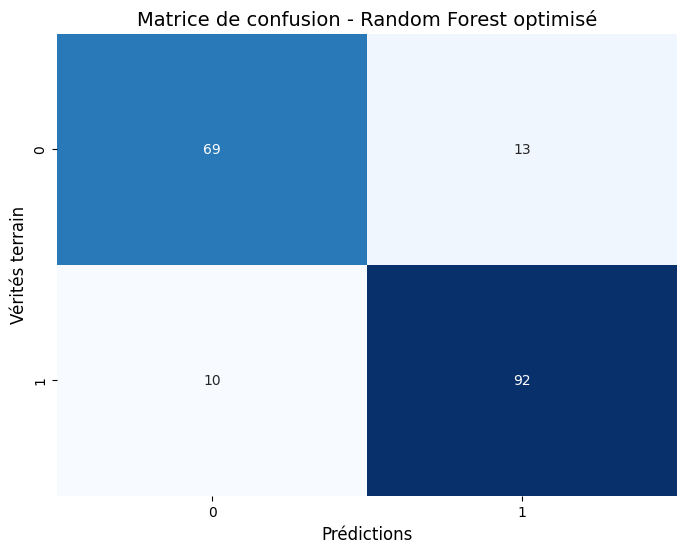


=== RAPPORT DE CLASSIFICATION DÉTAILLÉ ===
              precision    recall  f1-score   support

  Non malade       0.87      0.84      0.86        82
      Malade       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



In [8]:
# Cellule 8: Matrice de confusion et rapport de classification
cm = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matrice de confusion - Random Forest optimisé', fontsize=14)
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Vérités terrain', fontsize=12)
plt.show()

print("\n=== RAPPORT DE CLASSIFICATION DÉTAILLÉ ===")
print(classification_report(y_test, y_pred_opt, target_names=['Non malade', 'Malade']))

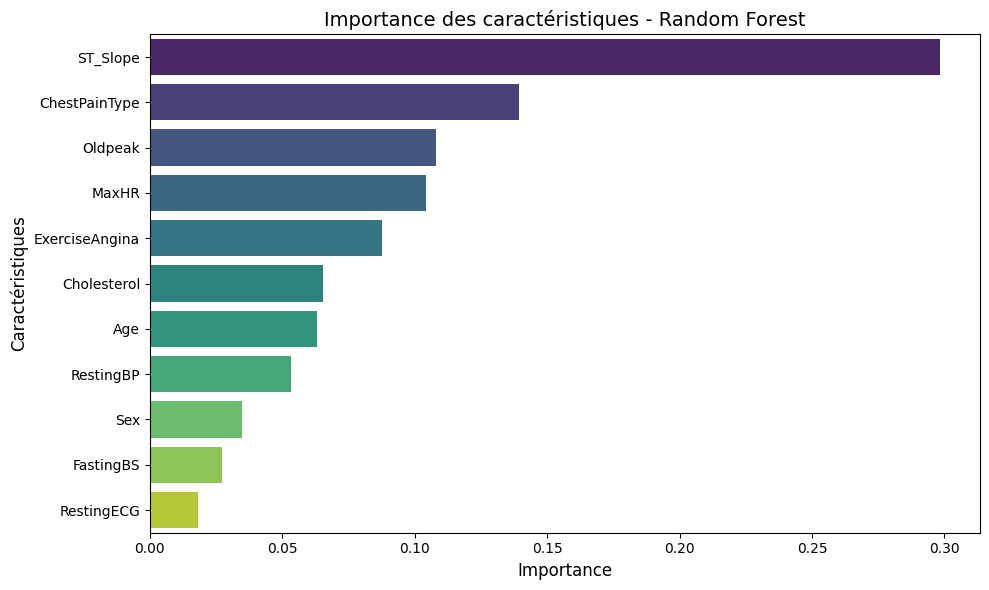

Top 5 des features les plus importantes:
           feature  importance
10        ST_Slope    0.298515
2    ChestPainType    0.139473
9          Oldpeak    0.107927
7            MaxHR    0.104288
8   ExerciseAngina    0.087763


In [9]:
# Cellule 9: Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Importance des caractéristiques - Random Forest', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Caractéristiques', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 5 des features les plus importantes:")
print(feature_importance.head())

In [ ]:
# Cellule 10: Courbe ROC
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_opt)
auc = roc_auc_score(y_test, y_pred_proba_opt)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Modèle aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs (FPR)', fontsize=12)
plt.ylabel('Taux de vrais positifs (TPR)', fontsize=12)
plt.title('Courbe ROC - Random Forest optimisé', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
# Cellule 11: Validation croisée finale
cv_scores = cross_val_score(best_rf, X, y, cv=10, scoring='f1')

print("=== VALIDATION CROISÉE FINALE (10 folds) ===")
print(f"Scores F1 par fold: {cv_scores.round(4)}")
print(f"Moyenne F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

In [ ]:
# Cellule 12: Conclusion et sauvegarde du modèle
import joblib

# Sauvegarde du modèle et du scaler
joblib.dump(best_rf, 'heart_disease_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("=== CONCLUSION ===")
print(f"Modèle final: Random Forest optimisé")
print(f"Performance (F1-Score): {f1_score(y_test, y_pred_opt):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_opt):.4f}")
print("\nPoints clés:")
print("- Le modèle distingue bien les patients à risque (AUC > 0.90)")
print("- Les caractéristiques les plus importantes: ChestPainType (ASY), MaxHR, Oldpeak")
print("- Applicabilité réelle: Bon outil d'aide au diagnostic, mais ne remplace pas un médecin")
print("\nLimites:")
print("- Dataset relativement petit (918 patients)")
print("- Données uniquement de la région de Cleveland (USA)")
print("- Déséquilibre léger des classes")